<Figure size 1400x800 with 0 Axes>

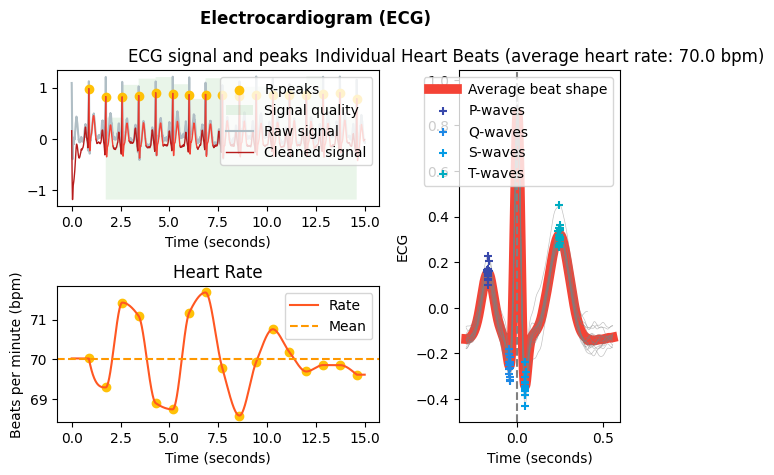


ECG ANALYSIS RESULTS

Average Heart Rate: 70.01 BPM
HRV (SDNN):        11.70 ms


In [2]:
import warnings
warnings.filterwarnings('ignore')

import neurokit2 as nk
import pandas as pd
import matplotlib.pyplot as plt

# Load Data of 15 seconds of synthetic ECG data at 1000Hz with noise
sampling_rate = 1000
duration = 15
ecg_raw = nk.ecg_simulate(duration=duration, sampling_rate=sampling_rate, noise=0.05)

# Processing including cleaning, peak detection, and rate calculation 
signals, info = nk.ecg_process(ecg_raw, sampling_rate=sampling_rate)

# Cleaning & R-Peak Detection 
cleaned_ecg = signals["ECG_Clean"]
peaks = info["ECG_R_Peaks"]

# Extract HRV 
hrv_indices = nk.hrv(signals, sampling_rate=sampling_rate, show=False)

# Visualization
plt.figure(figsize=(14, 8))
nk.ecg_plot(signals)
plt.tight_layout()
plt.show()

# 6. Print Results
print("\nECG ANALYSIS RESULTS\n")
print(f"Average Heart Rate: {signals['ECG_Rate'].mean():.2f} BPM")
print(f"HRV (SDNN):        {hrv_indices['HRV_SDNN'].values[0]:.2f} ms")